# Скетч: двуслойная модель «мягкие ткани — лёгкое» по эксперименту

**Два испытуемых** (у каждого своя толщина мягких тканей h):
- **Георгий** — h = 40 мм, файлы `<размер>georg.csv`;
- **Ник** — h = 15 мм, файлы `<размер>nik.csv`.

Канал `BASE_2_Ω` — размер-варьируемая сборка над лёгким (моделируем). Размер = L = 2a; a = L/2, b = a/(a/b).

**Графики:**
1. Обзор сигналов + кривая зондирования $Z_{баз}$(размер) — **для обоих испытуемых** (это данные).
2. Расчётное $\Delta Z_{дых}$(размер) при разных h (a/b=2) — **модель** (данные не нужны).
3. То же при разных a/b — для h=40 и h=15 — **модель**.
4. Множество решений $(\rho_1,\rho_2)$ по сигналам — **два испытуемых** (Георгий@40, Ник@15).

В заголовке каждого графика: **что зафиксировано** и **что варьируется**.

## §0. Назначение скетча и словарь терминов

Это предварительный (обзорный) расчёт двуслойной полубесконечной модели на данных эксперимента: проверка формы кривой зондирования и оценка расчётного дыхательного размаха импеданса. Строгие версии тех же расчётов вынесены в отдельные ноутбуки: разметка сигналов — [08](08_Скетч_разметки.ipynb), статическая оценка удельных сопротивлений — [09](09_Статическая_оценка_параметров.ipynb), систолические приращения — [11](11_Систолические_Δρ_и_задержка.ipynb).

### Словарь терминов
Основные термины (двуслойная полубесконечная модель, электродная сборка, тетраполярный метод, базовый и пульсовой импеданс каналов 1 и 2, прямая и обратная задача) определены в §0 ноутбука [09](09_Статическая_оценка_параметров.ipynb). Дополнительно используются:
- **Обратная задача по одному размеру** — восстановление удельного сопротивления лёгкого ρ₂ по измеренному импедансу при заданных удельном сопротивлении мягких тканей ρ₁ и толщине слоя мягких тканей h; решается численно, так как импеданс монотонен по ρ₂.
- **Кривая зондирования** — зависимость кажущегося удельного сопротивления (§0 [09]) от размера электродной сборки; её форма отражает переход от сопротивления мягких тканей к сопротивлению лёгкого.
- **Вентиляционный размах импеданса** — разность импеданса между вдохом и выдохом при одном размере сборки, обусловленная изменением сопротивления лёгкого при дыхании.

**Входные данные.** Толщина слоя мягких тканей h из компьютерной томографии: Георгий 40 мм, Ник 15 мм; путь к исходным записям и меткам.

**Допущения.** Толщина считается постоянной в пределах испытуемого; конфигурация задаёт общие для скетча параметры.

In [1]:
# @title Импорты и конфигурация
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
%matplotlib inline

ROOT = r"Z:\01 Project\01 Experiments\EXP_2026_04_29_BMSTU_REOCARDIO_GEORG_NIX"

# ====== ИСПЫТУЕМЫЕ: папка, шаблон имени файла, толщина h ======
SUBJECTS = {
    "Георгий": dict(dir=os.path.join(ROOT, "2026-04-29 Георгий Плыткевич"), pat="georg", h_mm=40),
    "Ник":     dict(dir=os.path.join(ROOT, "2026-04-29 Николай Калмыков"),  pat="nik",   h_mm=15),
}
BASE_COL = "BASE_2_Ω"     # моделируемый канал
REF_COL  = "BASE_1_Ω"     # референс

# ====== ГЕОМЕТРИЯ ======
AB_RATIO = 2.0            # a/b по умолчанию (a=L/2, b=a/AB_RATIO)

# ====== ПАРАМЕТРЫ МОДЕЛЬНЫХ ГРАФИКОВ (2,3) — дефолты, правьте ======
RHO1_MODEL = 5.0          # Ом·м, для модельных графиков dZ_дых
RHO2_EX    = 15.0         # лёгкое на выдохе, Ом·м
RHO2_IN    = 25.0         # лёгкое на вдохе,  Ом·м
H_LIST_MM  = [10, 20, 30, 40]     # h для графика 2
H_PAIR_MM  = [40, 15]             # две толщины для графика 3 (=толщины испытуемых)
AB_RATIOS  = [1.5, 2.0, 3.0, 4.0] # a/b для графика 3

# ====== ДИАПАЗОНЫ для множества решений (график 4) ======
RHO1_RANGE = (1.0, 20.0)
RHO2_RANGE = (2.0, 80.0)

NTERMS = 400

def ab_from_size(size_mm, ratio=AB_RATIO):
    # size_mm = L = 2a (мм) -> (a, b) в метрах
    a = size_mm/2/1000.0
    return a, a/ratio

print("Испытуемые:", ", ".join("%s (h=%d мм)" % (k, v["h_mm"]) for k, v in SUBJECTS.items()))

Испытуемые: Георгий (h=40 мм), Ник (h=15 мм)


**Анализ результатов.** Выведены испытуемые и их толщины.

**Результаты и умозаключения.** Конфигурация — общий вход для последующих ячеек скетча.

## §1. Двуслойная модель и обратная задача

**Входные данные.** Толщина h из томографии; исходные записи базового импеданса канала 2 и метки задержек дыхания из [08](08_Скетч_разметки.ipynb).

**Допущения.** Прямая задача — двуслойная полубесконечная модель (§0 [09](09_Статическая_оценка_параметров.ipynb)), формула (7.1):

$$Z=\frac{\rho_1}{\pi}\left(\frac{1}{a-b}-\frac{1}{a+b}\right)+\frac{2\rho_1}{\pi}\sum_{i=1}^{N}k^{\,i}\left(\frac{1}{\sqrt{(a-b)^2+(2ih)^2}}-\frac{1}{\sqrt{(a+b)^2+(2ih)^2}}\right) \tag{7.1}$$

где Z — импеданс сборки, Ом; ρ₁, ρ₂ — удельные сопротивления мягких тканей и лёгкого, Ом·м; a, b — половины токовой и потенциальной баз, м; h — толщина слоя мягких тканей, м; k = (ρ₂ − ρ₁)/(ρ₂ + ρ₁) — коэффициент отражения границы; N — число членов ряда. Обратная задача по одному размеру решается численно, так как импеданс монотонен по ρ₂.

In [2]:
# @title Двуслойная модель, обратная задача, загрузка
def Z_model(rho1, rho2, h, a, b, N=NTERMS):
    # импеданс тетраполярной сборки над двуслойной средой, Ом
    k = (rho2 - rho1)/(rho1 + rho2)
    d1, d2 = a - b, a + b
    i = np.arange(1, N+1)
    G1 = 1/np.sqrt(d1**2 + (2*i*h)**2)
    G2 = 1/np.sqrt(d2**2 + (2*i*h)**2)
    return rho1/np.pi*(1/d1 - 1/d2) + 2*rho1/np.pi*np.sum(k**i*(G1 - G2))

def rho_apparent(Z, a, b):
    # кажущееся ρ: обращение однослойной формулы (мелкая сборка -> ρ1)
    return Z*np.pi*(a**2 - b**2)/(2*b)

def solve_rho2(Z_target, rho1, h, a, b, lo, hi):
    # ρ2, дающее заданный Z (монотонно по ρ2); None если корня нет
    f = lambda r2: Z_model(rho1, r2, h, a, b) - Z_target
    if f(lo)*f(hi) > 0:
        return None
    return brentq(f, lo, hi)

def load_subject(d, pat):
    # возвращает {size: median BASE_2} и {size: df}
    Zb, dfs = {}, {}
    for path in glob.glob(os.path.join(d, "*%s.csv" % pat)):
        base = os.path.basename(path)
        if base.startswith("._"):
            continue
        m = re.match(r"(\d+)%s\.csv$" % pat, base)
        if not m:
            continue
        size = int(m.group(1))
        df = pd.read_csv(path, encoding="utf-8")
        dfs[size] = df
        Zb[size] = float(np.median(df[BASE_COL]))
    return dict(sorted(Zb.items())), dfs

DATA = {}
for name, info in SUBJECTS.items():
    Zb, dfs = load_subject(info["dir"], info["pat"])
    sizes = np.array(sorted(Zb.keys()))
    a0, b0 = ab_from_size(sizes[0])
    rho1_est = rho_apparent(Zb[sizes[0]], a0, b0)   # ρ1 из наименьшей сборки
    DATA[name] = dict(Zb=Zb, dfs=dfs, sizes=sizes, rho1=rho1_est, h=info["h_mm"]/1000.0)
    print("%-8s: размеры %s | ρ1≈%.2f Ом·м | h=%d мм"
          % (name, list(sizes), rho1_est, info["h_mm"]))

Георгий : размеры [np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100), np.int64(110), np.int64(120), np.int64(130), np.int64(140)] | ρ1≈11.52 Ом·м | h=40 мм
Ник     : размеры [np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100), np.int64(110), np.int64(120), np.int64(130), np.int64(140)] | ρ1≈5.00 Ом·м | h=15 мм


Ник     : размеры [np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100), np.int64(110), np.int64(120), np.int64(130), np.int64(140)] | ρ1≈5.00 Ом·м | h=15 мм


**Анализ результатов.** Модель и обратная задача определены; данные загружены, для каждого испытуемого доступен набор размеров сборок.

**Результаты и умозаключения.** Функции прямой и обратной задачи и загруженные данные — вход для §2 (кривые зондирования) и §3 (расчётный размах).

## §2. Обзор сигналов и кривая зондирования (оба испытуемых)

**Входные данные.** Одна исходная запись на испытуемого: базовый и пульсовой импеданс канала 2 и электрокардиограмма.

**Допущения.** Обзор временных рядов служит визуальной проверкой качества сигналов перед количественным анализом.

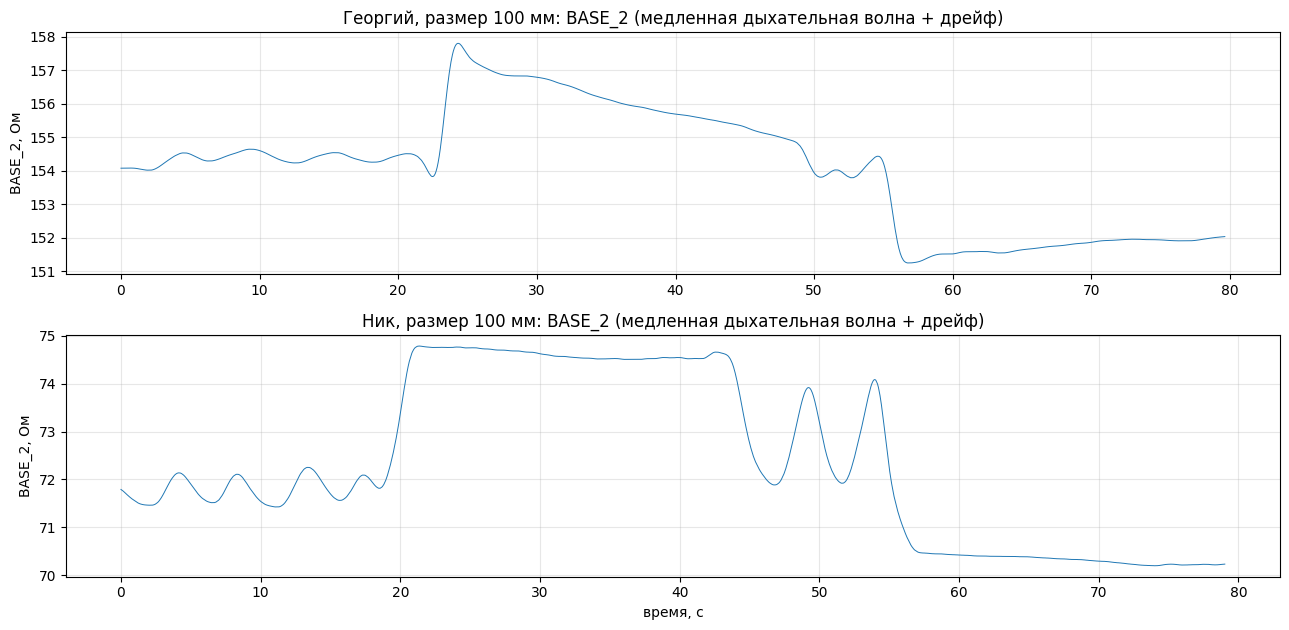

In [3]:
# @title Пример временных рядов (по одному файлу на испытуемого)
fig, axes = plt.subplots(len(SUBJECTS), 1, figsize=(13, 3.2*len(SUBJECTS)), sharex=False)
for ax, (name, D) in zip(np.atleast_1d(axes), DATA.items()):
    s = D["sizes"][len(D["sizes"])//2]
    df = D["dfs"][s]
    ax.plot(df["TIME_s"], df[BASE_COL], lw=0.7)
    ax.set_title("%s, размер %d мм: BASE_2 (медленная дыхательная волна + дрейф)" % (name, s))
    ax.set_ylabel("BASE_2, Ом"); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("время, с")
plt.tight_layout(); plt.show()

**Анализ результатов.** Показаны характерные временные ряды: медленная вентиляционная волна базового импеданса, сердечно-синхронный пульсовой импеданс и электрокардиограмма.

**Результаты и умозаключения.** Качество сигналов приемлемо для дальнейшего анализа; строгая сегментация выполняется в [08](08_Скетч_разметки.ipynb).

**Входные данные.** Базовый импеданс канала 2 на задержках дыхания по всем размерам сборок для обоих испытуемых.

**Допущения.** Строится кривая зондирования — зависимость кажущегося удельного сопротивления от размера сборки, формула (7.2):

$$\rho_a(L)=Z(L)\cdot\frac{\pi\,(a^2-b^2)}{2b} \tag{7.2}$$

где ρ_a — кажущееся удельное сопротивление, Ом·м; Z(L) — базовый импеданс сборки размера L, Ом; a, b — половины баз, м. Величина интерпретирующая (§0 [09]): при малом размере стремится к ρ₁, при большом — к ρ₂.

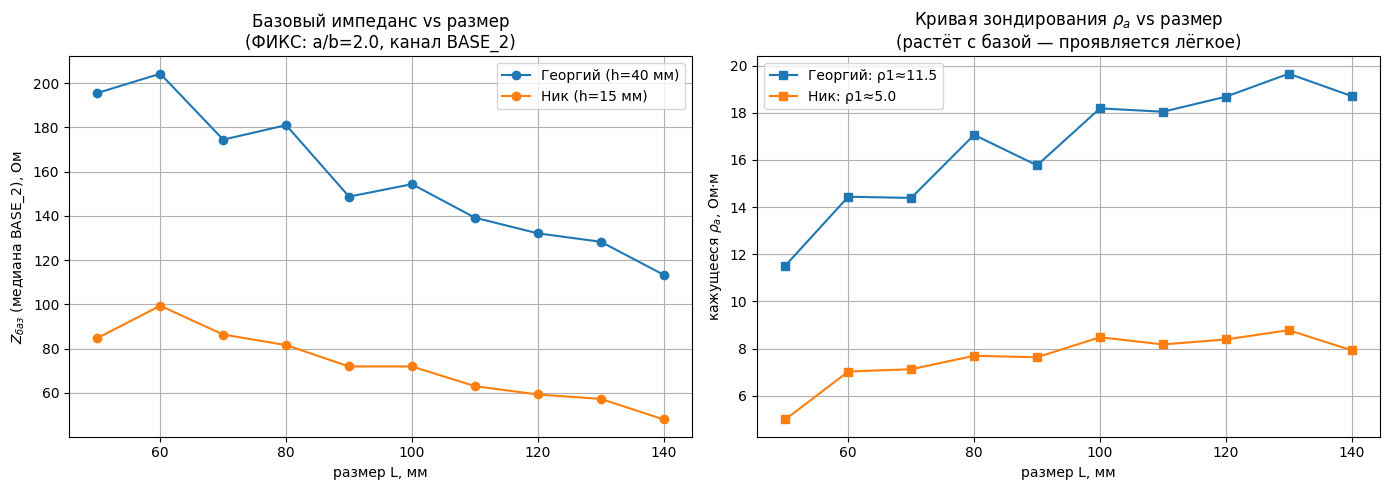

In [4]:
# @title Кривые зондирования для обоих испытуемых
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for name, D in DATA.items():
    sizes = D["sizes"]
    Zb = [D["Zb"][s] for s in sizes]
    ra = [rho_apparent(D["Zb"][s], *ab_from_size(s)) for s in sizes]
    ax[0].plot(sizes, Zb, "o-", label="%s (h=%d мм)" % (name, int(D["h"]*1000)))
    ax[1].plot(sizes, ra, "s-", label="%s: ρ1≈%.1f" % (name, D["rho1"]))
ax[0].set_xlabel("размер L, мм"); ax[0].set_ylabel("$Z_{баз}$ (медиана BASE_2), Ом")
ax[0].set_title("Базовый импеданс vs размер\n(ФИКС: a/b=%.1f, канал BASE_2)" % AB_RATIO)
ax[0].legend(); ax[0].grid(True)
ax[1].set_xlabel("размер L, мм"); ax[1].set_ylabel("кажущееся $\\rho_a$, Ом·м")
ax[1].set_title("Кривая зондирования $\\rho_a$ vs размер\n(растёт с базой — проявляется лёгкое)")
ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

**Анализ результатов.** Кривая зондирования у обоих испытуемых возрастает с размером сборки; у Ника (тонкий слой мягких тканей) возрастание выражено сильнее, у Георгия (толстый слой) — слабее.

**Результаты и умозаключения.** Форма кривых согласуется с моделью; количественная оценка удельных сопротивлений и их определимости — в [09](09_Статическая_оценка_параметров.ipynb).

## §3. Расчётный дыхательный размах $\Delta Z_{\text{вент}}$ (модель, без данных)

**Входные данные.** Прямая задача (7.1) при наборе значений толщины h и фиксированной форме сборки β = b/a = 0.5 (модельный расчёт, данные не используются).

**Допущения.** Расчётный дыхательный размах импеданса — разность модельного импеданса при вдохе и выдохе, формула (7.3):

$$\Delta Z_{\text{вент}}(L)=Z(\rho_1,\rho_2^{\text{вд}},h)-Z(\rho_1,\rho_2^{\text{выд}},h) \tag{7.3}$$

где ΔZ_вент — дыхательный размах импеданса, Ом; ρ₂вд, ρ₂выд — удельное сопротивление лёгкого на вдохе и выдохе, Ом·м. Расчёт модельный, без данных, для оценки ожидаемого сигнала.

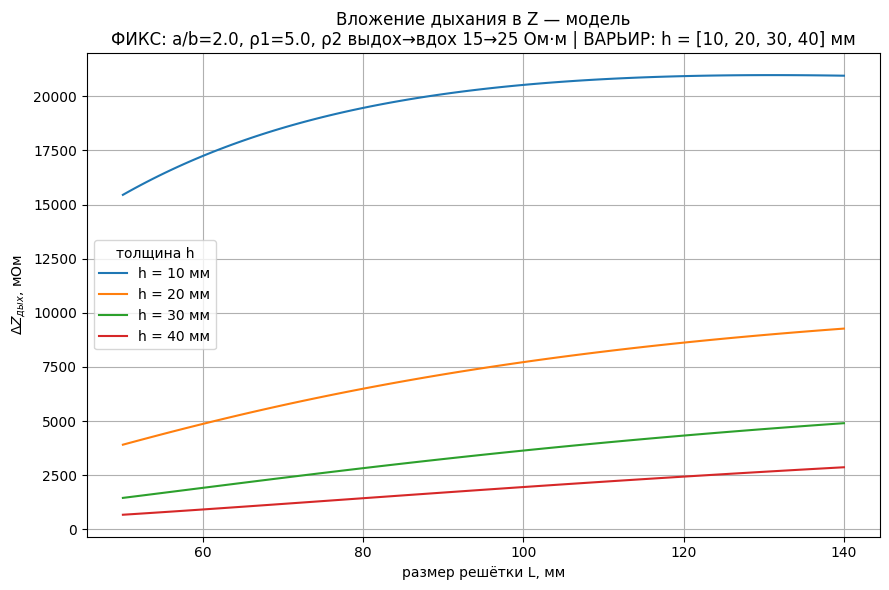

In [5]:
# @title График 2: dZ_дых(размер) для набора h (a/b=2)
Lscan = np.linspace(50, 140, 120)
plt.figure(figsize=(9, 6))
for h_mm in H_LIST_MM:
    h = h_mm/1000.0
    dZ = [ (Z_model(RHO1_MODEL, RHO2_IN, h, *ab_from_size(L)) -
            Z_model(RHO1_MODEL, RHO2_EX, h, *ab_from_size(L)))*1000 for L in Lscan ]
    plt.plot(Lscan, dZ, label="h = %d мм" % h_mm)
plt.xlabel("размер решётки L, мм"); plt.ylabel("$\\Delta Z_{дых}$, мОм")
plt.title("Вложение дыхания в Z — модель\n"
          "ФИКС: a/b=%.1f, ρ1=%.1f, ρ2 выдох→вдох %.0f→%.0f Ом·м | ВАРЬИР: h = %s мм"
          % (AB_RATIO, RHO1_MODEL, RHO2_EX, RHO2_IN, H_LIST_MM))
plt.legend(title="толщина h"); plt.grid(True); plt.tight_layout(); plt.show()

**Анализ результатов.** Расчётный дыхательный размах убывает с ростом размера сборки и с ростом толщины слоя мягких тканей; при толстом слое сигнал заметно слабее.

**Результаты и умозаключения.** При большой толщине дыхательный сигнал мал, что предвещает пониженную определимость ρ₂ у толстого испытуемого (строго — [09](09_Статическая_оценка_параметров.ipynb) §3.1).

**Входные данные.** Прямая задача (7.1) при наборе значений формы сборки β = b/a, отдельно для толщины 40 и 15 мм (модельный расчёт).

**Допущения.** Чтобы оценить влияние формы сборки на дыхательный сигнал, размах (7.3) вычисляется при разных β. Все реальные измерения выполнены при β = 0.5, поэтому результат по β — модельная оценка.

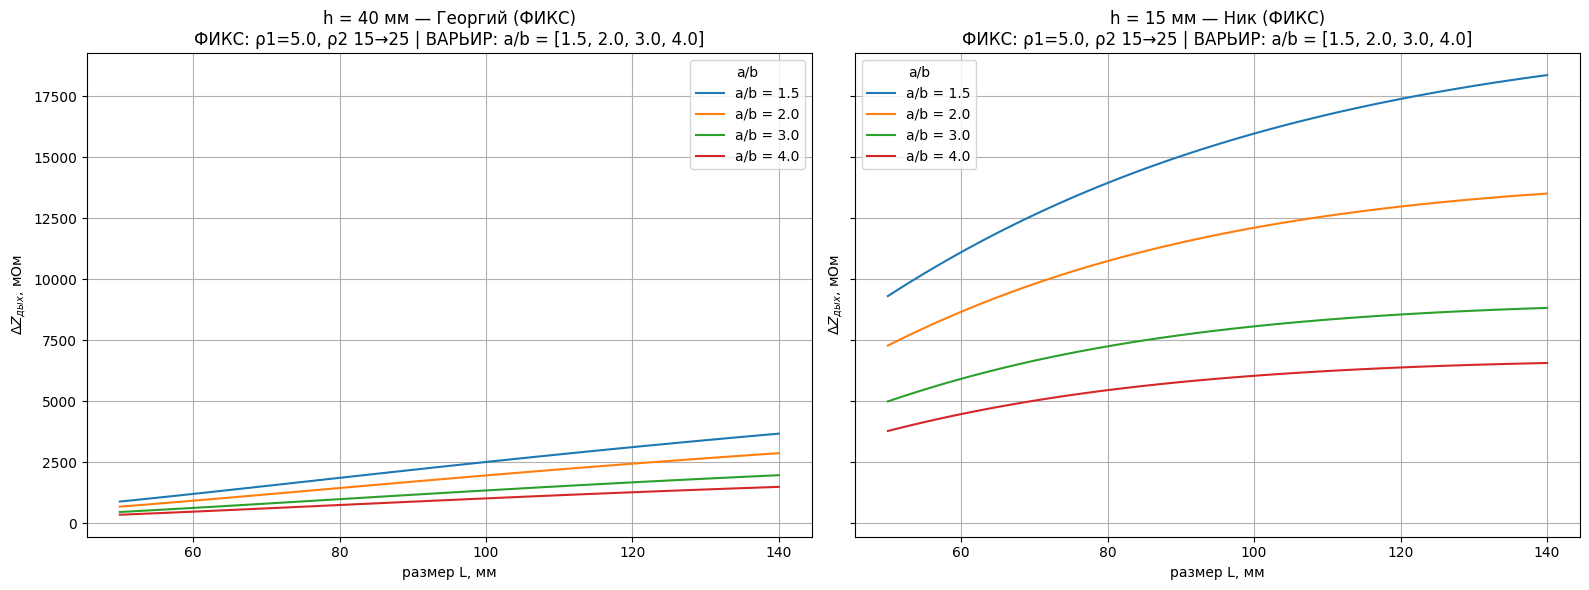

In [6]:
# @title График 3a/3b: dZ_дых(размер) для набора a/b, при h=40 и h=15
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
subj_by_h = {v["h_mm"]: k for k, v in SUBJECTS.items()}   # подпись, какой испытуемый
for ax, h_mm in zip(axes, H_PAIR_MM):
    h = h_mm/1000.0
    for ratio in AB_RATIOS:
        dZ = [ (Z_model(RHO1_MODEL, RHO2_IN, h, *ab_from_size(L, ratio)) -
                Z_model(RHO1_MODEL, RHO2_EX, h, *ab_from_size(L, ratio)))*1000 for L in Lscan ]
        ax.plot(Lscan, dZ, label="a/b = %.1f" % ratio)
    who = subj_by_h.get(h_mm, "")
    ax.set_xlabel("размер L, мм"); ax.set_ylabel("$\\Delta Z_{дых}$, мОм")
    ax.set_title("h = %d мм%s (ФИКС)\nФИКС: ρ1=%.1f, ρ2 %.0f→%.0f | ВАРЬИР: a/b = %s"
                 % (h_mm, (" — %s" % who) if who else "", RHO1_MODEL, RHO2_EX, RHO2_IN, AB_RATIOS))
    ax.legend(title="a/b"); ax.grid(True)
plt.tight_layout(); plt.show()

**Анализ результатов.** Дыхательный размах зависит от формы сборки: уменьшение β повышает размах, но одновременно снижает измеряемое напряжение.

**Результаты и умозаключения.** Оптимизация формы сборки — модельная рекомендация для будущих измерений; строгий расчёт по матрице Фишера — в [05](05_Анализ_чувствительности_решётки.ipynb) §8.